In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sawtooth
from scipy.optimize import curve_fit

In [220]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 20, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [221]:
data = pd.read_csv("5.36Hz2V.csv", sep = ";")

In [251]:
downsampling = 1000
i_min, i_max = (0,-1)
time = np.array(data["Time"][1::downsampling].str.replace(",", ".").astype(float))[i_min:i_max] / 1000 # s
channel_a = np.array(data["Channel A"][1::downsampling].str.replace(",", ".").astype(float))[i_min:i_max]
channel_b = np.array(data["Channel B"][1::downsampling].str.replace(",", ".").astype(float))[i_min:i_max]

Vmax = 2 # V
f = 5.36 # Hz
T = 1/f # s

In [244]:
lamb = 650e-9 # nm
init = channel_b[0]
sign = np.sign(channel_b[100] - channel_b[0])
if sign == 1:
    t0 =  init/Vmax * T/2
else:
    t0 = init/Vmax * T/2 + T/2

V = lambda t: Vmax/2 * sawtooth(2 * np.pi * f * (t + t0) , width=0.5) + Vmax/2
fit_func = lambda t, a, b, c, d: a*np.cos(2*np.pi / lamb * 2 * b * V(t) + c) + d

a0 = (channel_a.max() - channel_a.min()) / 2
b0 = 1e-7
c0 = 0
d0 = (channel_a.max() + channel_a.min()) / 2

p0 = [a0, b0, c0, d0]
print(p0)

bounds = ([0,-1, -np.pi, channel_a.min()-1], [2*a0,  1,    np.pi, channel_a.max()+1])

[2.4723179999999996, 1e-07, 0, 4.727793]


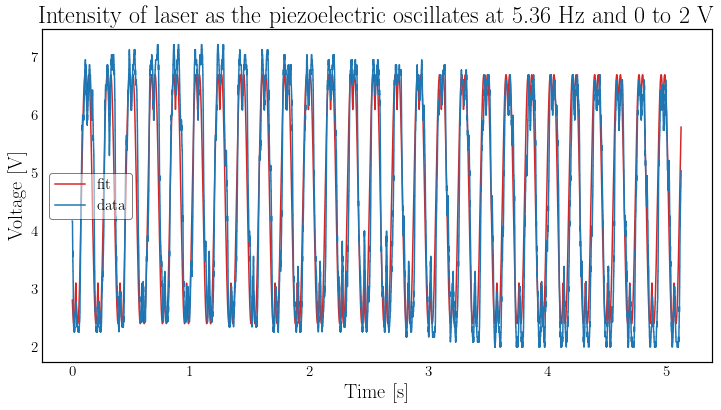

In [249]:
#time = time[0:10000]
#channel_a = channel_a[0:10000]

fig, ax = plt.subplots()
fit = curve_fit(fit_func, time, channel_a, p0, bounds = bounds, ftol=1e-12, xtol=1e-12, gtol=1e-12)
a,b,c,d = fit[0]
ax.plot(time, fit_func(time,a,b,c,d), color = "C3", label = "fit")
ax.plot(time, channel_a, color = "C0", label = "data")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title(f"Intensity of laser as the piezoelectric oscillates at {f} Hz and 0 to {Vmax} V")
ax.legend()